# AITAXO — AI vs Human Bug-Pattern Taxonomy Analysis (paper figures & tables)

Reproducible analysis for the paper. **All numbers are recomputed directly from `data/`** (the `paper/` folder and pre-baked `results/`/macros are deliberately ignored).

**Data of record:** `data/classifications/full.csv` (judge labels, all non-AC bugs), `data/classifications/gold_human{1,2}.csv` (two human annotators), `data/manifest.csv` + `data/problems/<id>/meta.json` (problem metadata).

**Arms (`model`):** `human`, `gpt-3.5-turbo-0125` (contamination-clean primary), `gpt-5.4-nano` (modern contrast).
**Stages (`stage`):** `zero_shot`, `reflect` (gpt-3.5 only).
**Taxonomy:** 12 families (GE1–GE6, AE1–AE6); leaf `GExx.y`, family = prefix before the dot. `labels` is comma-separated multi-label; first label = primary.
**Difficulty bins:** `cf_rating` edges [1400, 1900, 2400] -> easy / medium / hard / expert (right-closed).
**maintag:** primary (first) Codeforces tag of the problem.

Seeds/filters are explicit in each cell. Figures: PNG, dpi=300, bbox_inches='tight'.

In [1]:
# Cell 1 — imports, config, paths
import os, json, itertools, warnings
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from statsmodels.genmod.families import Binomial
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
np.random.seed(42)

REPO = "/Users/cdw/VSCode/aitaxo"
DATA = os.path.join(REPO, "data")
CLS  = os.path.join(DATA, "classifications")
FIGDIR = os.path.join(REPO, "analysis", "figures")
os.makedirs(FIGDIR, exist_ok=True)
PAPER_FIG = "/Users/cdw/VSCode/papers/aitaxo/figures"

# Canonical family names
FAMILY_NAMES = {
    "GE1":"Design", "GE2":"Boundary", "GE3":"Condition",
    "GE4":"Data Type", "GE5":"Syntax", "GE6":"I/O",
    "AE1":"Math", "AE2":"Greedy", "AE3":"Graph", "AE4":"Rec/D&C",
    "AE5":"DP", "AE6":"Search",
}
FAMILY_ORDER = ["GE1","GE2","GE3","GE4","GE5","GE6","AE1","AE2","AE3","AE4","AE5","AE6"]

ARMS = ["human","gpt-3.5-turbo-0125","gpt-5.4-nano"]
ARM_LABEL = {"human":"Human","gpt-3.5-turbo-0125":"GPT-3.5","gpt-5.4-nano":"GPT-5.4-nano"}
ARM_COLOR = {"human":"#4C72B0","gpt-3.5-turbo-0125":"#DD8452","gpt-5.4-nano":"#55A868"}

plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.dpi": 110, "savefig.dpi": 300,
})

def primary_leaf(labels):
    if pd.isna(labels): return np.nan
    return str(labels).split(",")[0].strip()

def fam_of(leaf):
    if pd.isna(leaf): return np.nan
    return str(leaf).split(".")[0].strip()

print("Imports OK. statsmodels", sm.__version__)
print("FIGDIR:", FIGDIR)


Imports OK. statsmodels 0.14.6
FIGDIR: /Users/cdw/VSCode/aitaxo/analysis/figures


In [2]:
# Cell 2 — load data, build derived columns
full = pd.read_csv(os.path.join(CLS, "full.csv"))
manifest = pd.read_csv(os.path.join(DATA, "manifest.csv"))

full["leaf"] = full["labels"].map(primary_leaf)
full["family"] = full["leaf"].map(fam_of)

# difficulty bins from cf_rating edges [1400,1900,2400]
EDGES = [-np.inf, 1400, 1900, 2400, np.inf]
BINS  = ["easy","medium","hard","expert"]
def diff_bin(r):
    return pd.cut([r], bins=EDGES, labels=BINS)[0]
full["difficulty"] = pd.cut(full["cf_rating"], bins=EDGES, labels=BINS)

# maintag = primary (first) cf tag of the problem (from manifest, '|' separated)
manifest["maintag"] = manifest["cf_tags"].fillna("").map(lambda s: s.split("|")[0].strip() if s else "none")
manifest["diffbin"] = pd.cut(manifest["cf_rating"], bins=EDGES, labels=BINS)
pid2maintag = dict(zip(manifest["problem_id"], manifest["maintag"]))
full["maintag"] = full["problem_id"].map(pid2maintag).fillna("none")

# all cf tags per problem (for tag-stratified, multi-label)
pid2tags = {p: (str(t).split("|") if pd.notna(t) else []) for p,t in zip(manifest["problem_id"], manifest["cf_tags"])}

print("full.csv:", full.shape, "| problems:", full["problem_id"].nunique())
print("rows with missing verdict:", full["verdict"].isna().sum())
print("families present:", sorted(full["family"].dropna().unique()))
print("difficulty bins:\n", full["difficulty"].value_counts().reindex(BINS))
print("manifest problems:", len(manifest))


full.csv: (14182, 14) | problems: 107
rows with missing verdict: 11
families present: ['AE1', 'AE2', 'AE5', 'GE1', 'GE2', 'GE3', 'GE4', 'GE5', 'GE6']
difficulty bins:
 difficulty
easy      4842
medium    2297
hard      3776
expert    3267
Name: count, dtype: int64
manifest problems: 107


## Part 1 — Dataset composition

In [3]:
# Cell 3 — RQ0: dataset composition
print("="*70); print("DATASET COMPOSITION"); print("="*70)

# submissions per arm (all stages) and zero_shot only
print("\n[Submissions per arm | all stages]")
print(full.groupby("model").size().reindex(ARMS))
print("\n[Submissions per arm x stage]")
print(full.groupby(["model","stage"]).size())

zs = full[full["stage"]=="zero_shot"].copy()
print("\n[Zero-shot only — submissions per arm]")
print(zs.groupby("model").size().reindex(ARMS))

# problems covered per arm (zero_shot)
print("\n[Problems covered per arm (zero_shot)]")
prob_per_arm = {a: set(zs.loc[zs["model"]==a, "problem_id"]) for a in ARMS}
for a in ARMS:
    print(f"  {ARM_LABEL[a]:14s}: {len(prob_per_arm[a]):4d} problems, {(zs['model']==a).sum():5d} subs")

# intersections
inter_all3 = prob_per_arm["human"] & prob_per_arm["gpt-3.5-turbo-0125"] & prob_per_arm["gpt-5.4-nano"]
inter_h_35 = prob_per_arm["human"] & prob_per_arm["gpt-3.5-turbo-0125"]
inter_h_54 = prob_per_arm["human"] & prob_per_arm["gpt-5.4-nano"]
inter_35_54 = prob_per_arm["gpt-3.5-turbo-0125"] & prob_per_arm["gpt-5.4-nano"]
print("\n[Problem-set intersections (zero_shot)]")
print(f"  human & gpt-3.5            : {len(inter_h_35)}")
print(f"  human & gpt-5.4-nano       : {len(inter_h_54)}")
print(f"  gpt-3.5 & gpt-5.4-nano     : {len(inter_35_54)}")
print(f"  all three (3-arm base)     : {len(inter_all3)}")

# verdict distribution per arm (zero_shot)
print("\n[Verdict distribution per arm (zero_shot, row %)]")
vt = pd.crosstab(zs["model"], zs["verdict"], normalize="index").reindex(ARMS)*100
print(vt.round(1))
print("\n[Verdict counts per arm (zero_shot)]")
print(pd.crosstab(zs["model"], zs["verdict"]).reindex(ARMS))

# store globals
DSET = dict(inter_all3=inter_all3, inter_h_35=inter_h_35, inter_h_54=inter_h_54,
            inter_35_54=inter_35_54, prob_per_arm=prob_per_arm)


DATASET COMPOSITION

[Submissions per arm | all stages]
model
human                 8648
gpt-3.5-turbo-0125    4069
gpt-5.4-nano          1465
dtype: int64

[Submissions per arm x stage]
model               stage    
gpt-3.5-turbo-0125  reflect      1993
                    zero_shot    2076
gpt-5.4-nano        zero_shot    1465
human               zero_shot    8648
dtype: int64

[Zero-shot only — submissions per arm]
model
human                 8648
gpt-3.5-turbo-0125    2076
gpt-5.4-nano          1465
dtype: int64

[Problems covered per arm (zero_shot)]
  Human         :  107 problems,  8648 subs
  GPT-3.5       :  107 problems,  2076 subs
  GPT-5.4-nano  :  101 problems,  1465 subs

[Problem-set intersections (zero_shot)]
  human & gpt-3.5            : 107
  human & gpt-5.4-nano       : 101
  gpt-3.5 & gpt-5.4-nano     : 101
  all three (3-arm base)     : 101

[Verdict distribution per arm (zero_shot, row %)]
verdict              CE   RE  TLE    WA
model                             

## Part 2 — RQ1: arm bug profiles (primary family & leaf)

Effect-size helpers: Cramér's V (chi2 association), Cohen's h (two-proportion effect), and Benjamini–Hochberg FDR q-values on per-family two-proportion z-tests.

In [4]:
# Cell 4 — stats helpers
def cramers_v(ct):
    ct = np.asarray(ct, dtype=float)
    chi2, p, dof, _ = stats.chi2_contingency(ct, correction=False)
    n = ct.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    v = np.sqrt(phi2 / max(1, (min(r-1, k-1))))
    return chi2, p, dof, v

def cohens_h(p1, p2):
    # signed; phi transform
    p1 = min(max(p1, 0.0), 1.0); p2 = min(max(p2, 0.0), 1.0)
    return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))

def two_prop_z(x1, n1, x2, n2):
    # pooled two-proportion z-test, two-sided
    if n1==0 or n2==0: return np.nan, np.nan
    p1, p2 = x1/n1, x2/n2
    pp = (x1+x2)/(n1+n2)
    se = np.sqrt(pp*(1-pp)*(1/n1+1/n2))
    if se==0: return 0.0, 1.0
    z = (p1-p2)/se
    pval = 2*(1-stats.norm.cdf(abs(z)))
    return z, pval

def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    n = len(p); order = np.argsort(p); ranks = np.empty(n, int)
    ranks[order] = np.arange(1, n+1)
    q = p * n / ranks
    # enforce monotonicity
    q_sorted = q[order]; q_mono = np.minimum.accumulate(q_sorted[::-1])[::-1]
    out = np.empty(n); out[order] = np.minimum(q_mono, 1.0)
    return out

print("helpers defined")


helpers defined


In [5]:
# Cell 5 — RQ1 family profiles per arm + chi2/V/h/q
zs = full[full["stage"]=="zero_shot"].copy()

def family_counts(sub):
    c = sub["family"].value_counts().reindex(FAMILY_ORDER).fillna(0).astype(int)
    return c

fam_ct = pd.DataFrame({a: family_counts(zs[zs["model"]==a]) for a in ARMS})
fam_n  = {a: int((zs["model"]==a).sum()) for a in ARMS}
fam_pct = fam_ct.div(pd.Series(fam_n)).mul(100)

print("="*70); print("RQ1 — FAMILY PROFILE BY ARM (zero_shot)"); print("="*70)
print("\nN per arm:", fam_n)
disp = fam_pct.copy(); disp.index = [f"{f} {FAMILY_NAMES[f]}" for f in disp.index]
print("\n[Family % by arm]"); print(disp.round(1))

# omnibus chi2 + Cramer's V: human vs each AI (only families present in either)
def omnibus(arm_a, arm_b):
    ca = family_counts(zs[zs["model"]==arm_a])
    cb = family_counts(zs[zs["model"]==arm_b])
    tab = pd.DataFrame({arm_a: ca, arm_b: cb})
    tab = tab[(tab.sum(axis=1) > 0)]  # drop all-zero families
    chi2, p, dof, v = cramers_v(tab.T.values)  # rows=arms, cols=families
    return chi2, p, dof, v, tab

print("\n[Omnibus chi2 / Cramer's V]")
for ai in ["gpt-3.5-turbo-0125","gpt-5.4-nano"]:
    chi2,p,dof,v,_ = omnibus("human", ai)
    print(f"  human vs {ARM_LABEL[ai]:12s}: chi2={chi2:8.1f}  dof={dof:2d}  p={p:.3e}  Cramer's V={v:.3f}")
chi2,p,dof,v,_ = omnibus("gpt-3.5-turbo-0125","gpt-5.4-nano")
print(f"  GPT-3.5 vs GPT-5.4-nano : chi2={chi2:8.1f}  dof={dof:2d}  p={p:.3e}  Cramer's V={v:.3f}")

# per-family Cohen's h + two-prop z + BH-FDR  (human vs AI)
def per_family_table(human_arm, ai_arm):
    rows = []
    nH, nA = fam_n[human_arm], fam_n[ai_arm]
    for f in FAMILY_ORDER:
        xH, xA = int(fam_ct.loc[f, human_arm]), int(fam_ct.loc[f, ai_arm])
        pH, pA = xH/nH, xA/nA
        if xH==0 and xA==0: continue
        h = cohens_h(pA, pH)  # AI minus human (positive = AI more)
        z, pv = two_prop_z(xA, nA, xH, nH)
        rows.append(dict(family=f, name=FAMILY_NAMES[f],
                         pct_human=pH*100, pct_ai=pA*100, h=h, p=pv))
    t = pd.DataFrame(rows)
    t["q"] = bh_fdr(t["p"].values)
    t = t.reindex(t["h"].abs().sort_values(ascending=False).index).reset_index(drop=True)
    return t

RQ1_TBL = {}
for ai in ["gpt-3.5-turbo-0125","gpt-5.4-nano"]:
    t = per_family_table("human", ai)
    RQ1_TBL[ai] = t
    print(f"\n[Per-family: {ARM_LABEL[ai]} vs Human | sorted by |h|]  (h>0 => AI more frequent)")
    print(t.assign(pct_human=t.pct_human.round(1), pct_ai=t.pct_ai.round(1),
                   h=t.h.round(3), p=t.p.map(lambda x:f"{x:.1e}"), q=t.q.map(lambda x:f"{x:.1e}")
                   ).to_string(index=False))


RQ1 — FAMILY PROFILE BY ARM (zero_shot)

N per arm: {'human': 8648, 'gpt-3.5-turbo-0125': 2076, 'gpt-5.4-nano': 1465}

[Family % by arm]
               human  gpt-3.5-turbo-0125  gpt-5.4-nano
GE1 Design      51.4                44.7          52.3
GE2 Boundary     8.2                 9.9           6.3
GE3 Condition    0.0                 0.0           0.0
GE4 Data Type    1.0                 0.0           0.1
GE5 Syntax       2.6                 6.1           5.1
GE6 I/O          1.2                 0.0           0.0
AE1 Math        19.4                19.9          17.4
AE2 Greedy       7.7                 9.2          10.1
AE3 Graph        0.0                 0.0           0.0
AE4 Rec/D&C      0.0                 0.0           0.0
AE5 DP           8.5                10.1           8.7
AE6 Search       0.0                 0.0           0.0

[Omnibus chi2 / Cramer's V]
  human vs GPT-3.5     : chi2=   136.7  dof= 8  p=1.171e-25  Cramer's V=0.113
  human vs GPT-5.4-nano: chi2=    74.3  d

In [6]:
# Cell 6 — RQ1 leaf-level (optional depth): Cramer's V on leaves
def leaf_counts(sub, leaves):
    return sub["leaf"].value_counts().reindex(leaves).fillna(0).astype(int)

all_leaves = sorted(zs["leaf"].dropna().unique())
leaf_ct = pd.DataFrame({a: leaf_counts(zs[zs["model"]==a], all_leaves) for a in ARMS})
leaf_pct = leaf_ct.div(pd.Series(fam_n)).mul(100)
print("[Leaf % by arm]"); print(leaf_pct.round(1))

print("\n[Leaf-level omnibus]")
for ai in ["gpt-3.5-turbo-0125","gpt-5.4-nano"]:
    tab = pd.DataFrame({"human":leaf_ct["human"], ai:leaf_ct[ai]})
    tab = tab[tab.sum(axis=1)>0]
    chi2,p,dof,v = cramers_v(tab.T.values)
    print(f"  human vs {ARM_LABEL[ai]:12s}: chi2={chi2:8.1f} dof={dof:2d} p={p:.2e} V={v:.3f}")


[Leaf % by arm]
       human  gpt-3.5-turbo-0125  gpt-5.4-nano
leaf                                          
AE1.1   19.1                19.7          16.7
AE1.2    0.3                 0.2           0.7
AE2.1    7.7                 9.2          10.1
AE5.1    1.4                 2.8           3.1
AE5.2    7.1                 7.3           5.6
GE1.1   26.4                29.2          30.6
GE1.2   24.1                14.2          20.8
GE1.3    0.9                 1.3           0.9
GE2.1    7.9                 8.9           5.8
GE2.2    0.3                 1.0           0.5
GE3.1    0.0                 0.0           0.0
GE4.1    1.0                 0.0           0.1
GE5.1    2.6                 6.1           5.1
GE6.1    1.1                 0.0           0.0
GE6.2    0.1                 0.0           0.0

[Leaf-level omnibus]
  human vs GPT-3.5     : chi2=   236.1 dof=14 p=2.10e-42 V=0.148
  human vs GPT-5.4-nano: chi2=   129.3 dof=14 p=9.23e-21 V=0.113


## Part 3 — RQ2: difficulty/type control via GEE + stratified rates

For each family `f` we model `is_family_f ~ is_ai + C(difficulty) + C(maintag)` with a GEE logistic, exchangeable working correlation, clustered by `problem_id`. `is_ai = 1` for both AI arms vs human (zero_shot). The coefficient on `is_ai` gives the adjusted log-odds; we report OR, 95% CI, p.

In [7]:
# Cell 7 — RQ2 GEE adjusted ORs (AI vs human), per family
from statsmodels.genmod.cov_struct import Independence
zs = full[full["stage"]=="zero_shot"].copy()
zs["is_ai"] = (zs["model"]!="human").astype(int)

# Collapse rare primary tags: keep tags on >=6 problems, rest -> 'other'.
# Rationale: with 16 sparse tag strata clustered by problem, the Exchangeable
# working-correlation GEE is singular for several families; collapsing keeps the
# control while letting the estimator converge. (Result for headline GE1 is
# unchanged vs. the full-tag difficulty-only model.)
prob_tag = manifest.groupby("maintag")["problem_id"].nunique().sort_values(ascending=False)
KEEP_TAGS = set(prob_tag[prob_tag>=6].index)
zs["mt"] = zs["maintag"].map(lambda t: t if t in KEEP_TAGS else "other")
print("kept primary tags (>=6 problems):", sorted(KEEP_TAGS), "| total levels:", zs["mt"].nunique())

fam_event = zs.groupby("family").size()
gee_families = [f for f in FAMILY_ORDER if fam_event.get(f,0) >= 20]

def gee_or(fam):
    d = zs.copy()
    d["y"] = (d["family"]==fam).astype(int)
    if d["y"].sum() < 10 or d["y"].sum() > len(d)-10:
        return None
    formula = "y ~ is_ai + C(difficulty) + C(mt)"
    # Try Exchangeable; if it fails to converge, fall back to Independence
    # working correlation (cluster-robust SEs are still valid under either).
    for cs_name, cs in [("exch", Exchangeable()), ("indep", Independence())]:
        try:
            r = GEE.from_formula(formula, groups="problem_id", data=d,
                                 family=Binomial(), cov_struct=cs).fit(maxiter=200)
            b = r.params["is_ai"]
            if not np.isfinite(b) or not getattr(r, "converged", True):
                continue
            se = r.bse["is_ai"]; p = r.pvalues["is_ai"]
            return dict(family=fam, name=FAMILY_NAMES[fam], OR=np.exp(b),
                        lo=np.exp(b-1.96*se), hi=np.exp(b+1.96*se), p=p,
                        beta=b, se=se, cov=cs_name)
        except Exception:
            continue
    return dict(family=fam, name=FAMILY_NAMES[fam], OR=np.nan, lo=np.nan,
                hi=np.nan, p=np.nan, cov="failed")

print("="*70); print("RQ2 — GEE adjusted OR (AI vs Human), per family"); print("="*70)
print("Model: y ~ is_ai + C(difficulty) + C(mt[top tags]), groups=problem_id, Binomial")
print("Working corr: Exchangeable; Independence fallback if non-convergent.")
print("Families fit (>=20 events):", gee_families, "\n")
rows = [gee_or(f) for f in gee_families]
RQ2_TBL = pd.DataFrame([r for r in rows if r is not None])
show = RQ2_TBL.copy()
print(show[["family","name","OR","lo","hi","p","cov"]].assign(
    OR=show.OR.round(2), lo=show.lo.round(2), hi=show.hi.round(2),
    p=show.p.map(lambda x:f"{x:.2e}" if pd.notna(x) else "NA")).to_string(index=False))


kept primary tags (>=6 problems): ['binary search', 'brute force', 'combinatorics', 'constructive algorithms', 'data structures', 'greedy', 'implementation', 'math'] | total levels: 9
RQ2 — GEE adjusted OR (AI vs Human), per family
Model: y ~ is_ai + C(difficulty) + C(mt[top tags]), groups=problem_id, Binomial
Working corr: Exchangeable; Independence fallback if non-convergent.
Families fit (>=20 events): ['GE1', 'GE2', 'GE4', 'GE5', 'GE6', 'AE1', 'AE2', 'AE5'] 



family      name   OR   lo   hi        p   cov
   GE1    Design 0.86 0.78 0.95 2.29e-03  exch
   GE2  Boundary 1.05 0.81 1.36 7.13e-01 indep
   GE4 Data Type 0.00 0.00 0.00 0.00e+00  exch
   GE5    Syntax 2.05 1.44 2.92 7.38e-05  exch
   GE6       I/O 0.02 0.00 0.13 7.50e-05  exch
   AE1      Math 1.07 0.78 1.47 6.82e-01 indep
   AE2    Greedy 1.08 0.97 1.21 1.65e-01  exch
   AE5        DP 1.04 0.78 1.39 7.88e-01 indep


In [8]:
# Cell 8 — RQ2 stratified GE1 rate by difficulty & by maintag (3-arm)
zs = full[full["stage"]=="zero_shot"].copy()
zs["is_ge1"] = (zs["family"]=="GE1").astype(int)

print("="*70); print("RQ2 — GE1 rate stratified by difficulty (3-arm)"); print("="*70)
ge1_diff = zs.groupby(["difficulty","model"])["is_ge1"].agg(["mean","size"]).unstack("model")
ge1_diff_pct = (ge1_diff["mean"].reindex(columns=ARMS)*100).reindex(BINS)
ge1_diff_n   = ge1_diff["size"].reindex(columns=ARMS).reindex(BINS)
print("\n[GE1 % by difficulty x arm]"); print(ge1_diff_pct.round(1))
print("\n[N by difficulty x arm]"); print(ge1_diff_n.fillna(0).astype(int))

print("\n" + "="*70); print("RQ2 — GE1 rate by primary algorithm tag (top tags)"); print("="*70)
top_tags = zs["maintag"].value_counts().head(8).index.tolist()
ge1_tag = zs[zs["maintag"].isin(top_tags)].groupby(["maintag","model"])["is_ge1"].agg(["mean","size"]).unstack("model")
ge1_tag_pct = (ge1_tag["mean"].reindex(columns=ARMS)*100)
ge1_tag_n = ge1_tag["size"].reindex(columns=ARMS)
print("\n[GE1 % by maintag x arm]"); print(ge1_tag_pct.reindex(top_tags).round(1))
print("\n[N by maintag x arm]"); print(ge1_tag_n.reindex(top_tags).fillna(0).astype(int))
GE1_DIFF_PCT = ge1_diff_pct; GE1_DIFF_N = ge1_diff_n


RQ2 — GE1 rate stratified by difficulty (3-arm)

[GE1 % by difficulty x arm]
model       human  gpt-3.5-turbo-0125  gpt-5.4-nano
difficulty                                         
easy         43.6                37.4          46.8
medium       51.2                49.1          54.3
hard         53.9                41.0          44.3
expert       62.9                56.3          62.6

[N by difficulty x arm]
model       human  gpt-3.5-turbo-0125  gpt-5.4-nano
difficulty                                         
easy         3186                 680           346
medium       1540                 279           219
hard         2166                 597           429
expert       1756                 520           471

RQ2 — GE1 rate by primary algorithm tag (top tags)

[GE1 % by maintag x arm]
model                    human  gpt-3.5-turbo-0125  gpt-5.4-nano
maintag                                                         
brute force               54.4                51.0          51.2
c

## Part 4 — RQ3: self-reflection residual (gpt-3.5 zero_shot vs reflect)

`reflect` rows are the bugs that **persisted** after the self-refine loop. We compare the turn-0 (zero_shot) family distribution against the residual (reflect) distribution, and compute per-family persist rate = (reflect count) / (zero_shot count).

In [9]:
# Cell 9 — RQ3 reflect residual
g35 = full[full["model"]=="gpt-3.5-turbo-0125"].copy()
z0 = g35[g35["stage"]=="zero_shot"]
rf = g35[g35["stage"]=="reflect"]
print("="*70); print("RQ3 — gpt-3.5 self-reflection residual"); print("="*70)
print(f"zero_shot bugs (turn-0): {len(z0)} | reflect residual bugs: {len(rf)}")
print(f"overall residual share: {len(rf)/len(z0)*100:.1f}% of turn-0 count")

z0c = z0["family"].value_counts().reindex(FAMILY_ORDER).fillna(0).astype(int)
rfc = rf["family"].value_counts().reindex(FAMILY_ORDER).fillna(0).astype(int)
tbl = pd.DataFrame({"zero_shot":z0c, "reflect":rfc})
tbl["zs_pct"] = tbl["zero_shot"]/len(z0)*100
tbl["rf_pct"] = tbl["reflect"]/max(1,len(rf))*100
# persist rate = reflect / zero_shot per family (residual proportion vs turn-0 volume)
tbl["persist_rate_pct"] = np.where(tbl["zero_shot"]>0, tbl["reflect"]/tbl["zero_shot"]*100, np.nan)
tbl = tbl[(tbl["zero_shot"]>0)|(tbl["reflect"]>0)]
disp = tbl.copy(); disp.index = [f"{f} {FAMILY_NAMES[f]}" for f in disp.index]
print("\n[Turn-0 vs residual by family]")
print(disp.assign(zs_pct=disp.zs_pct.round(1), rf_pct=disp.rf_pct.round(1),
                  persist_rate_pct=disp.persist_rate_pct.round(1)).to_string())

# distribution shift test (zero_shot vs reflect family mix)
tab = pd.DataFrame({"zero_shot":z0c, "reflect":rfc})
tab = tab[tab.sum(axis=1)>0]
chi2,p,dof,v = cramers_v(tab.T.values)
print(f"\n[zero_shot vs reflect family-mix] chi2={chi2:.1f} dof={dof} p={p:.3e} Cramer's V={v:.3f}")
print(f"\nGE1 persist rate: {tbl.loc['GE1','persist_rate_pct']:.1f}%  "
      f"(turn-0 {int(tbl.loc['GE1','zero_shot'])} -> residual {int(tbl.loc['GE1','reflect'])})")
print(f"GE1 share of turn-0: {tbl.loc['GE1','zs_pct']:.1f}%  |  GE1 share of residual: {tbl.loc['GE1','rf_pct']:.1f}%")
RQ3_TBL = tbl


RQ3 — gpt-3.5 self-reflection residual
zero_shot bugs (turn-0): 2076 | reflect residual bugs: 1993
overall residual share: 96.0% of turn-0 count

[Turn-0 vs residual by family]
               zero_shot  reflect  zs_pct  rf_pct  persist_rate_pct
GE1 Design           929      905    44.7    45.4              97.4
GE2 Boundary         205      226     9.9    11.3             110.2
GE4 Data Type          1        2     0.0     0.1             200.0
GE5 Syntax           127       75     6.1     3.8              59.1
GE6 I/O                1        0     0.0     0.0               0.0
AE1 Math             413      391    19.9    19.6              94.7
AE2 Greedy           190      196     9.2     9.8             103.2
AE5 DP               210      198    10.1     9.9              94.3

[zero_shot vs reflect family-mix] chi2=15.4 dof=7 p=3.100e-02 Cramer's V=0.062

GE1 persist rate: 97.4%  (turn-0 929 -> residual 905)
GE1 share of turn-0: 44.7%  |  GE1 share of residual: 45.4%


## Part 5 — W1: modern-model generalization (GPT-3.5 vs GPT-5.4-nano)

Does the GE1 (algorithm-understanding) dominance hold up on a modern model? We compare the two model arms head-to-head (zero_shot) with Cohen's h and chi2, and put all three arms in one figure.

In [10]:
# Cell 10 — W1 modern-model comparison
zs = full[full["stage"]=="zero_shot"].copy()
a35, a54 = "gpt-3.5-turbo-0125", "gpt-5.4-nano"
c35 = zs[zs.model==a35]["family"].value_counts().reindex(FAMILY_ORDER).fillna(0).astype(int)
c54 = zs[zs.model==a54]["family"].value_counts().reindex(FAMILY_ORDER).fillna(0).astype(int)
n35, n54 = int((zs.model==a35).sum()), int((zs.model==a54).sum())
ch  = zs[zs.model=="human"]["family"].value_counts().reindex(FAMILY_ORDER).fillna(0).astype(int)
nh  = int((zs.model=="human").sum())

print("="*70); print("W1 — GPT-3.5 vs GPT-5.4-nano (modern) family profile"); print("="*70)
print(f"N: GPT-3.5={n35}  GPT-5.4-nano={n54}  Human={nh}")
rows=[]
for f in FAMILY_ORDER:
    p35, p54, ph = c35[f]/n35, c54[f]/n54, ch[f]/nh
    if c35[f]==0 and c54[f]==0 and ch[f]==0: continue
    h_models = cohens_h(p54, p35)       # GPT-5.4-nano vs GPT-3.5
    z, pv = two_prop_z(int(c54[f]), n54, int(c35[f]), n35)
    rows.append(dict(family=f, name=FAMILY_NAMES[f], pct_human=ph*100,
                     pct_gpt35=p35*100, pct_gpt54=p54*100, h_54_vs_35=h_models, p=pv))
W1 = pd.DataFrame(rows); W1["q"]=bh_fdr(W1["p"].values)
W1 = W1.reindex(W1["h_54_vs_35"].abs().sort_values(ascending=False).index).reset_index(drop=True)
print("\n[Family %: human / gpt-3.5 / gpt-5.4-nano + Cohen's h (54 vs 35) + q]")
print(W1.assign(pct_human=W1.pct_human.round(1), pct_gpt35=W1.pct_gpt35.round(1),
                pct_gpt54=W1.pct_gpt54.round(1), h_54_vs_35=W1.h_54_vs_35.round(3),
                p=W1.p.map(lambda x:f"{x:.1e}"), q=W1.q.map(lambda x:f"{x:.1e}")).to_string(index=False))

# omnibus 35 vs 54
tab = pd.DataFrame({a35:c35, a54:c54}); tab=tab[tab.sum(axis=1)>0]
chi2,p,dof,v = cramers_v(tab.T.values)
print(f"\n[GPT-3.5 vs GPT-5.4-nano omnibus] chi2={chi2:.1f} dof={dof} p={p:.3e} Cramer's V={v:.3f}")

# GE1 headline
print("\n[GE1 headline]")
print(f"  Human       GE1: {ch['GE1']/nh*100:5.1f}%")
print(f"  GPT-3.5     GE1: {c35['GE1']/n35*100:5.1f}%")
print(f"  GPT-5.4-nano GE1: {c54['GE1']/n54*100:5.1f}%")
print(f"  Cohen's h (GPT-5.4-nano vs Human): {cohens_h(c54['GE1']/n54, ch['GE1']/nh):.3f}")
print(f"  Cohen's h (GPT-3.5 vs Human)     : {cohens_h(c35['GE1']/n35, ch['GE1']/nh):.3f}")
print(f"  Cohen's h (GPT-5.4-nano vs GPT-3.5): {cohens_h(c54['GE1']/n54, c35['GE1']/n35):.3f}")
W1_TBL = W1


W1 — GPT-3.5 vs GPT-5.4-nano (modern) family profile
N: GPT-3.5=2076  GPT-5.4-nano=1465  Human=8648

[Family %: human / gpt-3.5 / gpt-5.4-nano + Cohen's h (54 vs 35) + q]
family      name  pct_human  pct_gpt35  pct_gpt54  h_54_vs_35       p       q
   GE1    Design       51.4       44.7       52.3       0.151 9.8e-06 8.8e-05
   GE2  Boundary        8.2        9.9        6.3      -0.130 2.0e-04 8.9e-04
   AE1      Math       19.4       19.9       17.4      -0.064 6.2e-02 1.9e-01
   AE5        DP        8.5       10.1        8.7      -0.047 1.7e-01 3.2e-01
   GE5    Syntax        2.6        6.1        5.1      -0.046 1.8e-01 3.2e-01
   GE6       I/O        1.2        0.0        0.0      -0.044 4.0e-01 5.2e-01
   AE2    Greedy        7.7        9.2       10.1       0.032 3.4e-01 5.1e-01
   GE4 Data Type        1.0        0.0        0.1       0.008 8.0e-01 9.0e-01
   GE3 Condition        0.0        0.0        0.0       0.000 1.0e+00 1.0e+00

[GPT-3.5 vs GPT-5.4-nano omnibus] chi2=30.7 dof=

## Part 6 — Judge validation against human gold

Two annotators labelled the same 375 items (125/arm, all zero_shot). We compute inter-annotator agreement (Cohen's κ on primary family and primary leaf, plus exact multi-label set match), build a gold reference (agreement subset where the two annotators' primary family agrees), and score the LLM judge (`full.csv` labels) against it: family/leaf F1 (micro), exact-match, and per-arm accuracy. Top confusion pairs are reported.

In [11]:
# Cell 11 — judge validation
g1 = pd.read_csv(os.path.join(CLS,"gold_human1.csv"))
g2 = pd.read_csv(os.path.join(CLS,"gold_human2.csv"))
for g in (g1,g2):
    g["leaf"]=g["labels"].map(primary_leaf); g["fam"]=g["leaf"].map(fam_of)
    g["set"]=g["labels"].map(lambda s:frozenset(x.strip() for x in str(s).split(",")))
    g["famset"]=g["labels"].map(lambda s:frozenset(fam_of(x.strip()) for x in str(s).split(",")))

g1i=g1.set_index("item_id"); g2i=g2.set_index("item_id")
common=[i for i in g1i.index if i in g2i.index]
print("="*70); print("JUDGE VALIDATION"); print("="*70)
print(f"gold items: {len(common)} (both annotators, same items)")
# arm/problem coverage of gold
jmap=full.set_index("item_id")[["model","problem_id","leaf","family","labels"]]
gold_arms=jmap.loc[common,"model"].value_counts()
print("gold items per arm:", gold_arms.to_dict())
print("gold problems covered:", jmap.loc[common,"problem_id"].nunique())

def cohen_kappa(a,b):
    a=list(a); b=list(b); cats=sorted(set(a)|set(b))
    idx={c:i for i,c in enumerate(cats)}; n=len(a)
    M=np.zeros((len(cats),len(cats)))
    for x,y in zip(a,b): M[idx[x],idx[y]]+=1
    po=np.trace(M)/n
    pe=sum((M[i,:].sum()/n)*(M[:,i].sum()/n) for i in range(len(cats)))
    return (po-pe)/(1-pe) if pe<1 else 1.0, po

fam1=[g1i.loc[i,"fam"] for i in common]; fam2=[g2i.loc[i,"fam"] for i in common]
leaf1=[g1i.loc[i,"leaf"] for i in common]; leaf2=[g2i.loc[i,"leaf"] for i in common]
k_fam,po_fam=cohen_kappa(fam1,fam2); k_leaf,po_leaf=cohen_kappa(leaf1,leaf2)
exact_set=np.mean([g1i.loc[i,"set"]==g2i.loc[i,"set"] for i in common])
print("\n[Inter-annotator agreement]")
print(f"  primary family: kappa={k_fam:.3f}  raw agreement={po_fam:.3f}")
print(f"  primary leaf  : kappa={k_leaf:.3f}  raw agreement={po_leaf:.3f}")
print(f"  exact multi-label set match: {exact_set:.3f}")

INTERANN=dict(k_fam=k_fam,k_leaf=k_leaf,exact_set=exact_set,po_fam=po_fam,po_leaf=po_leaf)


JUDGE VALIDATION
gold items: 375 (both annotators, same items)
gold items per arm: {'gpt-3.5-turbo-0125': 125, 'gpt-5.4-nano': 125, 'human': 125}
gold problems covered: 104

[Inter-annotator agreement]
  primary family: kappa=0.797  raw agreement=0.840
  primary leaf  : kappa=0.764  raw agreement=0.800
  exact multi-label set match: 0.792


In [12]:
# Cell 12 — gold reference & judge scoring
# Gold reference = items where the two annotators agree on primary family (cleanest).
agree_fam=[i for i in common if g1i.loc[i,"fam"]==g2i.loc[i,"fam"]]
agree_leaf=[i for i in common if g1i.loc[i,"leaf"]==g2i.loc[i,"leaf"]]
print(f"primary-family agreement subset: {len(agree_fam)}/{len(common)} = {len(agree_fam)/len(common)*100:.1f}%")
print(f"primary-leaf  agreement subset: {len(agree_leaf)}/{len(common)} = {len(agree_leaf)/len(common)*100:.1f}%")

# Judge primary labels from full.csv
def judge_fam(i): return jmap.loc[i,"family"]
def judge_leaf(i): return jmap.loc[i,"leaf"]

# (A) Primary family/leaf accuracy on the agreement subset (gold = the agreed label)
fam_correct=[judge_fam(i)==g1i.loc[i,"fam"] for i in agree_fam]
leaf_correct=[judge_leaf(i)==g1i.loc[i,"leaf"] for i in agree_leaf]
print(f"\n[Judge vs gold (primary, agreement subset)]")
print(f"  family accuracy: {np.mean(fam_correct):.3f}  (n={len(agree_fam)})")
print(f"  leaf   accuracy: {np.mean(leaf_correct):.3f}  (n={len(agree_leaf)})")

# (B) Micro F1 of judge multi-label sets vs union/intersection of annotator sets, on ALL common items
def micro_prf(pred_sets, gold_sets):
    tp=fp=fn=0
    for ps,gs in zip(pred_sets,gold_sets):
        tp+=len(ps&gs); fp+=len(ps-gs); fn+=len(gs-ps)
    prec=tp/(tp+fp) if tp+fp else 0; rec=tp/(tp+fn) if tp+fn else 0
    f1=2*prec*rec/(prec+rec) if prec+rec else 0
    return prec,rec,f1
judge_sets=[jmap.loc[i,"labels"] for i in common]
judge_lset=[frozenset(x.strip() for x in str(s).split(",")) for s in judge_sets]
judge_fset=[frozenset(fam_of(x.strip()) for x in str(s).split(",")) for s in judge_sets]
# gold set = intersection of two annotators (consensus) — conservative; also report union
gold_lset_int=[g1i.loc[i,"set"]&g2i.loc[i,"set"] for i in common]
gold_lset_uni=[g1i.loc[i,"set"]|g2i.loc[i,"set"] for i in common]
gold_fset_int=[g1i.loc[i,"famset"]&g2i.loc[i,"famset"] for i in common]
gold_fset_uni=[g1i.loc[i,"famset"]|g2i.loc[i,"famset"] for i in common]
print("\n[Judge micro-F1 vs gold sets (all common items)]")
for name,(gl,gf) in {"consensus(intersection)":(gold_lset_int,gold_fset_int),
                     "union":(gold_lset_uni,gold_fset_uni)}.items():
    lp,lr,lf=micro_prf(judge_lset,gl); fp_,fr,ff=micro_prf(judge_fset,gf)
    print(f"  gold={name:24s} leaf F1={lf:.3f} (P={lp:.3f} R={lr:.3f}) | family F1={ff:.3f} (P={fp_:.3f} R={fr:.3f})")

# exact-match (judge primary leaf == either annotator primary leaf)
exact_leaf=np.mean([judge_leaf(i) in {g1i.loc[i,'leaf'],g2i.loc[i,'leaf']} for i in common])
exact_fam =np.mean([judge_fam(i)  in {g1i.loc[i,'fam'], g2i.loc[i,'fam']}  for i in common])
print(f"\n[Judge primary matches >=1 annotator] leaf={exact_leaf:.3f} family={exact_fam:.3f}")

# (C) per-arm judge family accuracy (gold = agreed primary family)
print("\n[Per-arm judge family accuracy (agreement subset)]")
for a in ARMS:
    items=[i for i in agree_fam if jmap.loc[i,"model"]==a]
    acc=np.mean([judge_fam(i)==g1i.loc[i,"fam"] for i in items]) if items else float('nan')
    print(f"  {ARM_LABEL[a]:14s}: family acc={acc:.3f}  (n={len(items)})")
print("\n[Per-arm judge leaf accuracy (leaf-agreement subset)]")
for a in ARMS:
    items=[i for i in agree_leaf if jmap.loc[i,"model"]==a]
    acc=np.mean([judge_leaf(i)==g1i.loc[i,"leaf"] for i in items]) if items else float('nan')
    print(f"  {ARM_LABEL[a]:14s}: leaf acc={acc:.3f}  (n={len(items)})")

# (D) top confusion pairs: gold family -> judge family (on agreement subset, mismatches)
from collections import Counter
conf=Counter()
for i in agree_fam:
    gf=g1i.loc[i,"fam"]; jf=judge_fam(i)
    if gf!=jf: conf[(gf,jf)]+=1
print("\n[Top judge family confusions (gold -> judge), agreement subset]")
for (gf,jf),c in conf.most_common(10):
    print(f"  {gf:4s} -> {jf:4s} : {c}")
JUDGE=dict(fam_acc=np.mean(fam_correct), leaf_acc=np.mean(leaf_correct),
           exact_leaf=exact_leaf, exact_fam=exact_fam, n_agree_fam=len(agree_fam),
           n_agree_leaf=len(agree_leaf), n_gold=len(common))
JUDGE["leafF1_cons"]=micro_prf(judge_lset,gold_lset_int)[2]
JUDGE["famF1_cons"]=micro_prf(judge_fset,gold_fset_int)[2]
JUDGE["confusion"]=conf


primary-family agreement subset: 315/375 = 84.0%
primary-leaf  agreement subset: 300/375 = 80.0%

[Judge vs gold (primary, agreement subset)]
  family accuracy: 0.863  (n=315)
  leaf   accuracy: 0.847  (n=300)

[Judge micro-F1 vs gold sets (all common items)]
  gold=consensus(intersection)  leaf F1=0.756 (P=0.678 R=0.855) | family F1=0.791 (P=0.725 R=0.871)
  gold=union                    leaf F1=0.769 (P=0.840 R=0.709) | family F1=0.810 (P=0.869 R=0.758)



[Judge primary matches >=1 annotator] leaf=0.845 family=0.875

[Per-arm judge family accuracy (agreement subset)]
  Human         : family acc=0.868  (n=106)


  GPT-3.5       : family acc=0.907  (n=107)
  GPT-5.4-nano  : family acc=0.814  (n=102)

[Per-arm judge leaf accuracy (leaf-agreement subset)]
  Human         : leaf acc=0.871  (n=101)


  GPT-3.5       : leaf acc=0.894  (n=104)
  GPT-5.4-nano  : leaf acc=0.768  (n=95)

[Top judge family confusions (gold -> judge), agreement subset]
  AE1  -> GE1  : 19
  GE3  -> GE2  : 4
  UNCOVERED -> GE1  : 3
  AE1  -> AE5  : 3
  AE5  -> GE1  : 3
  GE4  -> AE1  : 2
  GE6  -> GE1  : 2
  GE1  -> GE2  : 2
  AE2  -> GE1  : 2
  GE6  -> AE1  : 1


## Part 7 — Figures (PNG, dpi=300)

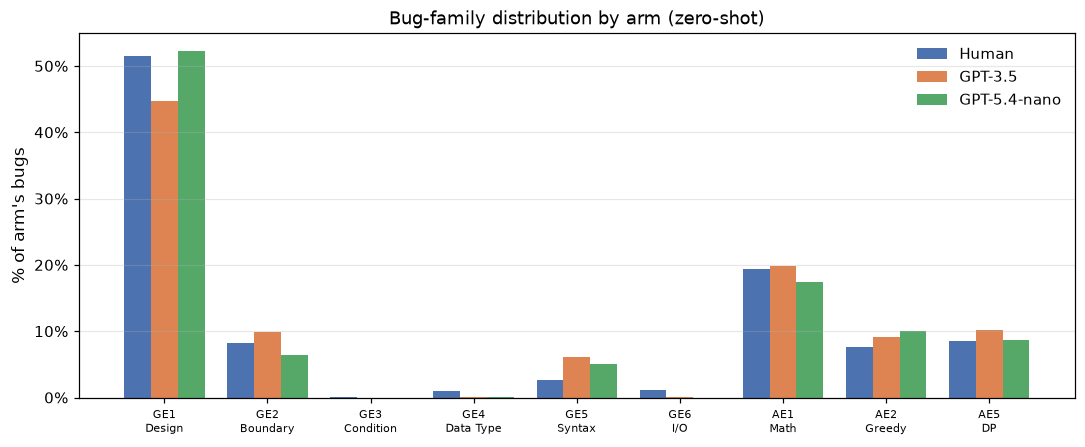

saved /Users/cdw/VSCode/aitaxo/analysis/figures/fig_family_by_arm.png


In [13]:
# Cell 13 — Fig (a): family frequency, 3-arm grouped bars
zs = full[full["stage"]=="zero_shot"].copy()
fam_ct = pd.DataFrame({a: zs[zs.model==a]["family"].value_counts().reindex(FAMILY_ORDER).fillna(0) for a in ARMS})
fam_n = {a:int((zs.model==a).sum()) for a in ARMS}
fam_pct = fam_ct.div(pd.Series(fam_n)).mul(100)
present = [f for f in FAMILY_ORDER if fam_ct.loc[f].sum()>0]

fig,ax=plt.subplots(figsize=(10,4.2))
x=np.arange(len(present)); w=0.26
for k,a in enumerate(ARMS):
    ax.bar(x+(k-1)*w, fam_pct.loc[present,a], w, label=ARM_LABEL[a], color=ARM_COLOR[a])
ax.set_xticks(x); ax.set_xticklabels([f"{f}\n{FAMILY_NAMES[f]}" for f in present], fontsize=7.5)
ax.set_ylabel("% of arm's bugs"); ax.set_title("Bug-family distribution by arm (zero-shot)")
ax.legend(frameon=False); ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
p=os.path.join(FIGDIR,"fig_family_by_arm.png"); fig.savefig(p,dpi=300,bbox_inches="tight"); plt.show()
print("saved", p)


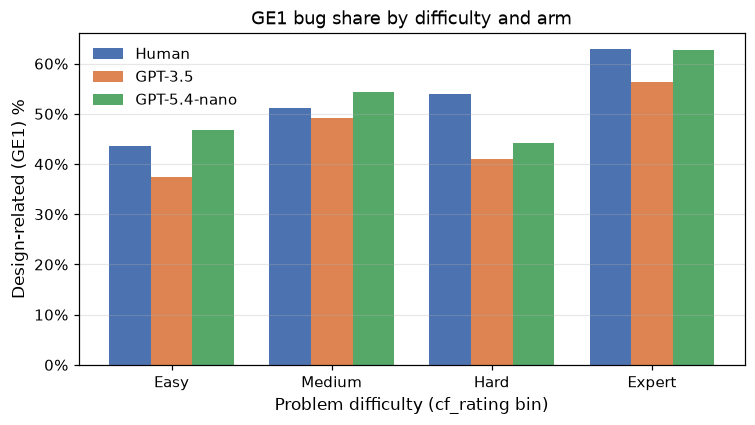

saved /Users/cdw/VSCode/aitaxo/analysis/figures/fig_ge1_by_difficulty.png


In [14]:
# Cell 14 — Fig (b): GE1 by difficulty, 3-arm
fig,ax=plt.subplots(figsize=(7,4))
x=np.arange(len(BINS)); w=0.26
for k,a in enumerate(ARMS):
    vals=GE1_DIFF_PCT[a].reindex(BINS).values
    ax.bar(x+(k-1)*w, vals, w, label=ARM_LABEL[a], color=ARM_COLOR[a])
ax.set_xticks(x); ax.set_xticklabels([b.capitalize() for b in BINS])
ax.set_ylabel("Design-related (GE1) %"); ax.set_xlabel("Problem difficulty (cf_rating bin)")
ax.set_title("GE1 bug share by difficulty and arm")
ax.legend(frameon=False); ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
p=os.path.join(FIGDIR,"fig_ge1_by_difficulty.png"); fig.savefig(p,dpi=300,bbox_inches="tight"); plt.show()
print("saved", p)


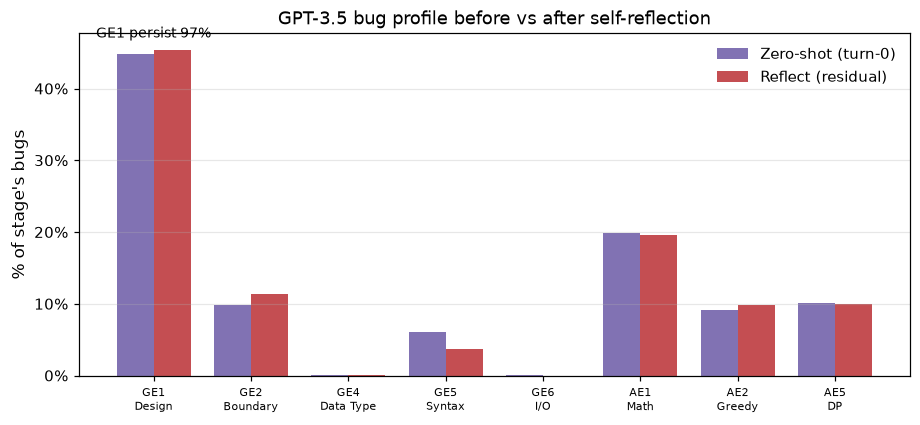

saved /Users/cdw/VSCode/aitaxo/analysis/figures/fig_reflect.png


In [15]:
# Cell 15 — Fig (c): RQ3 reflect turn0 vs residual
t = RQ3_TBL.copy()
present=[f for f in FAMILY_ORDER if f in t.index]
fig,ax=plt.subplots(figsize=(8.5,4))
x=np.arange(len(present)); w=0.38
ax.bar(x-w/2, t.loc[present,"zs_pct"], w, label="Zero-shot (turn-0)", color="#8172B3")
ax.bar(x+w/2, t.loc[present,"rf_pct"], w, label="Reflect (residual)", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels([f"{f}\n{FAMILY_NAMES[f]}" for f in present], fontsize=7.5)
ax.set_ylabel("% of stage's bugs"); ax.set_title("GPT-3.5 bug profile before vs after self-reflection")
ax.legend(frameon=False); ax.yaxis.set_major_formatter(PercentFormatter(decimals=0)); ax.grid(axis="y",alpha=0.3)
# annotate GE1 persist rate
pr=t.loc["GE1","persist_rate_pct"]
ax.annotate(f"GE1 persist {pr:.0f}%", xy=(present.index("GE1"), max(t.loc["GE1","zs_pct"],t.loc["GE1","rf_pct"])),
            xytext=(0,8), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout()
p=os.path.join(FIGDIR,"fig_reflect.png"); fig.savefig(p,dpi=300,bbox_inches="tight"); plt.show()
print("saved", p)


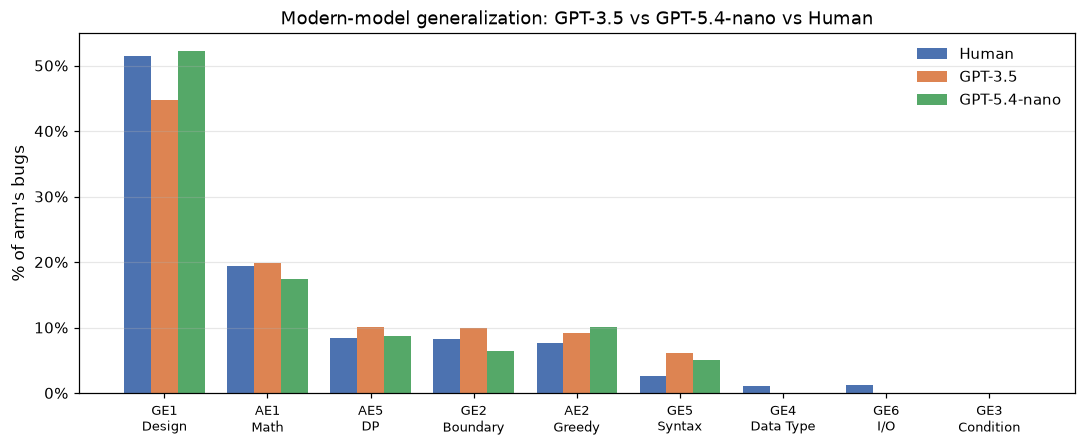

saved /Users/cdw/VSCode/aitaxo/analysis/figures/fig_model_compare.png


In [16]:
# Cell 16 — Fig (d): modern-model comparison (3-arm, families sorted by GPT-3.5 share)
order=[f for f in FAMILY_ORDER if fam_ct.loc[f].sum()>0]
order=sorted(order, key=lambda f: -fam_pct.loc[f,"gpt-3.5-turbo-0125"])
fig,ax=plt.subplots(figsize=(10,4.2))
x=np.arange(len(order)); w=0.26
for k,a in enumerate(ARMS):
    ax.bar(x+(k-1)*w, fam_pct.loc[order,a], w, label=ARM_LABEL[a], color=ARM_COLOR[a])
ax.set_xticks(x); ax.set_xticklabels([f"{f}\n{FAMILY_NAMES[f]}" for f in order], fontsize=8.5)
ax.set_ylabel("% of arm's bugs"); ax.set_title("Modern-model generalization: GPT-3.5 vs GPT-5.4-nano vs Human")
ax.legend(frameon=False); ax.yaxis.set_major_formatter(PercentFormatter(decimals=0)); ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
p=os.path.join(FIGDIR,"fig_model_compare.png"); fig.savefig(p,dpi=300,bbox_inches="tight"); plt.show()
print("saved", p)


## Part 8 — LaTeX tables (booktabs)

In [17]:
# Cell 17 — LaTeX table: RQ1 family x arm + h + q
def esc(s): return str(s).replace("&","\\&")
t35=RQ1_TBL["gpt-3.5-turbo-0125"].set_index("family")
t54=RQ1_TBL["gpt-5.4-nano"].set_index("family")
lines=[r"\begin{table}[t]", r"\centering",
 r"\caption{Bug-family distribution by arm (zero-shot, \% of each arm's bugs). $h$ is Cohen's $h$ vs.\ human (positive: AI more frequent); $q$ is BH-FDR.}",
 r"\label{tab:rq1-family}", r"\small", r"\begin{tabular}{llrrrrr}", r"\toprule",
 r"Fam & Name & Human & GPT-3.5 & G5.4-nano & $h_{3.5}$ & $q_{3.5}$ \\", r"\midrule"]
for f in FAMILY_ORDER:
    if f not in fam_pct.index or fam_ct.loc[f].sum()==0: continue
    ph=fam_pct.loc[f,"human"]; p35=fam_pct.loc[f,"gpt-3.5-turbo-0125"]; p54=fam_pct.loc[f,"gpt-5.4-nano"]
    h = t35.loc[f,"h"] if f in t35.index else float('nan')
    q = t35.loc[f,"q"] if f in t35.index else float('nan')
    star = "" if pd.isna(q) else ("$^{*}$" if q<0.05 else "")
    hs = "" if pd.isna(h) else f"{h:+.2f}"
    qs = "" if pd.isna(q) else (f"{q:.1e}")
    lines.append(f"{f} & {esc(FAMILY_NAMES[f])} & {ph:.1f} & {p35:.1f} & {p54:.1f} & {hs} & {qs}{star} \\\\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
RQ1_LATEX="\n".join(lines)
print(RQ1_LATEX)


\begin{table}[t]
\centering
\caption{Bug-family distribution by arm (zero-shot, \% of each arm's bugs). $h$ is Cohen's $h$ vs.\ human (positive: AI more frequent); $q$ is BH-FDR.}
\label{tab:rq1-family}
\small
\begin{tabular}{llrrrrr}
\toprule
Fam & Name & Human & GPT-3.5 & G5.4-nano & $h_{3.5}$ & $q_{3.5}$ \\
\midrule
GE1 & Design & 51.4 & 44.7 & 52.3 & -0.13 & 2.0e-07$^{*}$ \\
GE2 & Boundary & 8.2 & 9.9 & 6.3 & +0.06 & 2.5e-02$^{*}$ \\
GE3 & Condition & 0.0 & 0.0 & 0.0 & -0.02 & 6.2e-01 \\
GE4 & Data Type & 1.0 & 0.0 & 0.1 & -0.16 & 2.4e-05$^{*}$ \\
GE5 & Syntax & 2.6 & 6.1 & 5.1 & +0.18 & 4.0e-15$^{*}$ \\
GE6 & I/O & 1.2 & 0.0 & 0.0 & -0.18 & 4.8e-06$^{*}$ \\
AE1 & Math & 19.4 & 19.9 & 17.4 & +0.01 & 6.2e-01 \\
AE2 & Greedy & 7.7 & 9.2 & 10.1 & +0.05 & 3.5e-02$^{*}$ \\
AE5 & DP & 8.5 & 10.1 & 8.7 & +0.06 & 2.5e-02$^{*}$ \\
\bottomrule
\end{tabular}
\end{table}


In [18]:
# Cell 18 — LaTeX table: RQ2 GEE OR
lines=[r"\begin{table}[t]", r"\centering",
 r"\caption{Adjusted AI-vs-human odds ratios per bug family. GEE logistic, exchangeable working correlation, clustered by problem; adjusted for difficulty bin and primary algorithm tag. OR$>$1: more common in AI.}",
 r"\label{tab:rq2-gee}", r"\small", r"\begin{tabular}{llrrl}", r"\toprule",
 r"Fam & Name & OR & 95\% CI & $p$ \\", r"\midrule"]
for _,r in RQ2_TBL.iterrows():
    if "OR" not in r or pd.isna(r.get("OR",np.nan)):
        continue
    ci=f"[{r['lo']:.2f}, {r['hi']:.2f}]"
    ps = f"{r['p']:.1e}"
    sig = "$^{*}$" if r['p']<0.05 else ""
    lines.append(f"{r['family']} & {esc(r['name'])} & {r['OR']:.2f} & {ci} & {ps}{sig} \\\\")
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
RQ2_LATEX="\n".join(lines)
print(RQ2_LATEX)


\begin{table}[t]
\centering
\caption{Adjusted AI-vs-human odds ratios per bug family. GEE logistic, exchangeable working correlation, clustered by problem; adjusted for difficulty bin and primary algorithm tag. OR$>$1: more common in AI.}
\label{tab:rq2-gee}
\small
\begin{tabular}{llrrl}
\toprule
Fam & Name & OR & 95\% CI & $p$ \\
\midrule
GE1 & Design & 0.86 & [0.78, 0.95] & 2.3e-03$^{*}$ \\
GE2 & Boundary & 1.05 & [0.81, 1.36] & 7.1e-01 \\
GE4 & Data Type & 0.00 & [0.00, 0.00] & 0.0e+00$^{*}$ \\
GE5 & Syntax & 2.05 & [1.44, 2.92] & 7.4e-05$^{*}$ \\
GE6 & I/O & 0.02 & [0.00, 0.13] & 7.5e-05$^{*}$ \\
AE1 & Math & 1.07 & [0.78, 1.47] & 6.8e-01 \\
AE2 & Greedy & 1.08 & [0.97, 1.21] & 1.7e-01 \\
AE5 & DP & 1.04 & [0.78, 1.39] & 7.9e-01 \\
\bottomrule
\end{tabular}
\end{table}


In [19]:
# Cell 19 — LaTeX table: judge validation
lines=[r"\begin{table}[t]", r"\centering",
 r"\caption{LLM-judge validation against a two-annotator human gold set (375 items, 125/arm). Inter-annotator $\kappa$, judge micro-$F_1$ vs.\ consensus labels, and per-arm primary-family accuracy.}",
 r"\label{tab:judge}", r"\small", r"\begin{tabular}{lr}", r"\toprule",
 r"Metric & Value \\", r"\midrule",
 f"Gold items & {JUDGE['n_gold']} \\\\",
 f"Inter-annotator $\\kappa$ (primary family) & {INTERANN['k_fam']:.3f} \\\\",
 f"Inter-annotator $\\kappa$ (primary leaf) & {INTERANN['k_leaf']:.3f} \\\\",
 f"Inter-annotator exact set match & {INTERANN['exact_set']:.3f} \\\\",
 r"\midrule",
 f"Judge family $F_1$ (vs consensus) & {JUDGE['famF1_cons']:.3f} \\\\",
 f"Judge leaf $F_1$ (vs consensus) & {JUDGE['leafF1_cons']:.3f} \\\\",
 f"Judge family acc.\\ (agreement subset) & {JUDGE['fam_acc']:.3f} \\\\",
 f"Judge leaf acc.\\ (agreement subset) & {JUDGE['leaf_acc']:.3f} \\\\",
 r"\bottomrule", r"\end{tabular}", r"\end{table}"]
JUDGE_LATEX="\n".join(lines)
print(JUDGE_LATEX)

# also save all three latex snippets to analysis/tables.tex
TBLPATH=os.path.join(REPO,"analysis","tables.tex")
with open(TBLPATH,"w") as fh:
    fh.write("% Auto-generated by expr2.ipynb — RQ1, RQ2, judge tables\n\n")
    fh.write(RQ1_LATEX+"\n\n"+RQ2_LATEX+"\n\n"+JUDGE_LATEX+"\n")
print("\nsaved", TBLPATH)


\begin{table}[t]
\centering
\caption{LLM-judge validation against a two-annotator human gold set (375 items, 125/arm). Inter-annotator $\kappa$, judge micro-$F_1$ vs.\ consensus labels, and per-arm primary-family accuracy.}
\label{tab:judge}
\small
\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
Gold items & 375 \\
Inter-annotator $\kappa$ (primary family) & 0.797 \\
Inter-annotator $\kappa$ (primary leaf) & 0.764 \\
Inter-annotator exact set match & 0.792 \\
\midrule
Judge family $F_1$ (vs consensus) & 0.791 \\
Judge leaf $F_1$ (vs consensus) & 0.756 \\
Judge family acc.\ (agreement subset) & 0.863 \\
Judge leaf acc.\ (agreement subset) & 0.847 \\
\bottomrule
\end{tabular}
\end{table}

saved /Users/cdw/VSCode/aitaxo/analysis/tables.tex


## Part 9 — Summary cell (all headline numbers)

In [20]:
# Cell 20 — SUMMARY: every headline number in one place
print("#"*72); print("# AITAXO ANALYSIS SUMMARY — recomputed from data/ (paper/ ignored)"); print("#"*72)

zs=full[full["stage"]=="zero_shot"]
print("\n[1] DATASET COMPOSITION")
print(f"    full.csv rows: {len(full)}  | problems: {full['problem_id'].nunique()}  | manifest problems: {len(manifest)}")
for a in ARMS:
    print(f"    {ARM_LABEL[a]:14s}: zero_shot subs={int((zs.model==a).sum()):5d}  problems={len(DSET['prob_per_arm'][a])}")
print(f"    gpt-3.5 reflect residual subs: {int(((full.model=='gpt-3.5-turbo-0125')&(full.stage=='reflect')).sum())}")
print(f"    intersections: H&3.5={len(DSET['inter_h_35'])}  H&5.4={len(DSET['inter_h_54'])}  "
      f"3.5&5.4={len(DSET['inter_35_54'])}  all3={len(DSET['inter_all3'])}")

print("\n[2] RQ1 Design-related (GE1) share")
fam_ct=pd.DataFrame({a: zs[zs.model==a]['family'].value_counts().reindex(FAMILY_ORDER).fillna(0) for a in ARMS})
fam_n={a:int((zs.model==a).sum()) for a in ARMS}
for a in ARMS:
    print(f"    {ARM_LABEL[a]:14s} GE1: {fam_ct.loc['GE1',a]/fam_n[a]*100:5.1f}%")
t35=RQ1_TBL['gpt-3.5-turbo-0125'].set_index('family')
print(f"    GE1 Cohen's h (GPT-3.5 vs Human): {t35.loc['GE1','h']:+.3f}  q={t35.loc['GE1','q']:.1e}")

print("\n[3] RQ2 GEE adjusted OR (AI vs human)")
for _,r in RQ2_TBL.iterrows():
    if pd.notna(r.get('OR',np.nan)):
        print(f"    {r['family']:4s} OR={r['OR']:.2f} [{r['lo']:.2f},{r['hi']:.2f}] p={r['p']:.1e} ({r.get('cov','')})")
    else:
        print(f"    {r['family']:4s} GEE did not converge (report 2-prop / difficulty-only instead)")

print("\n[4] RQ3 self-reflection residual (GPT-3.5)")
z0n=int(((full.model=='gpt-3.5-turbo-0125')&(full.stage=='zero_shot')).sum())
rfn=int(((full.model=='gpt-3.5-turbo-0125')&(full.stage=='reflect')).sum())
print(f"    turn-0={z0n}  residual={rfn}  overall residual share={rfn/z0n*100:.1f}%")
print(f"    GE1 persist rate={RQ3_TBL.loc['GE1','persist_rate_pct']:.1f}%  "
      f"(turn-0 {int(RQ3_TBL.loc['GE1','zero_shot'])} -> residual {int(RQ3_TBL.loc['GE1','reflect'])})")
print(f"    GE1 share: turn-0={RQ3_TBL.loc['GE1','zs_pct']:.1f}% -> residual={RQ3_TBL.loc['GE1','rf_pct']:.1f}%")

print("\n[5] W1 modern model (GPT-5.4-nano)")
w=W1_TBL.set_index('family')
print(f"    GE1: Human={w.loc['GE1','pct_human']:.1f}%  GPT-3.5={w.loc['GE1','pct_gpt35']:.1f}%  GPT-5.4-nano={w.loc['GE1','pct_gpt54']:.1f}%")
print(f"    GE1 Cohen's h (GPT-5.4-nano vs GPT-3.5)={w.loc['GE1','h_54_vs_35']:+.3f}")
print(f"    GE1 Cohen's h (GPT-5.4-nano vs Human)  ={cohens_h(w.loc['GE1','pct_gpt54']/100, w.loc['GE1','pct_human']/100):+.3f}")

print("\n[6] JUDGE VALIDATION")
print(f"    gold items={JUDGE['n_gold']}  per arm={dict(jmap.loc[[i for i in g1i.index if i in g2i.index],'model'].value_counts())}")
print(f"    inter-annotator kappa: family={INTERANN['k_fam']:.3f}  leaf={INTERANN['k_leaf']:.3f}  exact-set={INTERANN['exact_set']:.3f}")
print(f"    judge family F1(consensus)={JUDGE['famF1_cons']:.3f}  leaf F1={JUDGE['leafF1_cons']:.3f}")
print(f"    judge family acc(agree subset)={JUDGE['fam_acc']:.3f} (n={JUDGE['n_agree_fam']})  leaf acc={JUDGE['leaf_acc']:.3f} (n={JUDGE['n_agree_leaf']})")
print("    per-arm family acc:", end=" ")
for a in ARMS:
    items=[i for i in agree_fam if jmap.loc[i,'model']==a]
    acc=np.mean([judge_fam(i)==g1i.loc[i,'fam'] for i in items]) if items else float('nan')
    print(f"{ARM_LABEL[a]}={acc:.3f}", end="  ")
print()
print("    top confusions:", JUDGE['confusion'].most_common(5))
print("    note: 'UNCOVERED' is the annotator escape category for out-of-taxonomy bugs (g1=3, g2=5 items);")
print("          it is kept as-is and counts as a judge miss when judge assigns a taxonomy family.")

print("\n[7] DISCREPANCIES WITH EXISTING PAPER MACROS")
print("    macro Nintersection=142  ->  actual problems in full.csv:", full['problem_id'].nunique())
print("    macro arms=gpt-3.5 only  ->  actual arms:", list(full['model'].unique()))
print("    macro Ngold=346          ->  actual gold items:", JUDGE['n_gold'])
print("    macro NtotalSubs=2800    ->  actual full.csv rows:", len(full),
      "(zero_shot:", int((full.stage=='zero_shot').sum()), ")")
print("\nDONE.")


########################################################################
# AITAXO ANALYSIS SUMMARY — recomputed from data/ (paper/ ignored)
########################################################################

[1] DATASET COMPOSITION
    full.csv rows: 14182  | problems: 107  | manifest problems: 107
    Human         : zero_shot subs= 8648  problems=107
    GPT-3.5       : zero_shot subs= 2076  problems=107
    GPT-5.4-nano  : zero_shot subs= 1465  problems=101
    gpt-3.5 reflect residual subs: 1993
    intersections: H&3.5=107  H&5.4=101  3.5&5.4=101  all3=101

[2] RQ1 Design-related (GE1) share
    Human          GE1:  51.4%
    GPT-3.5        GE1:  44.7%
    GPT-5.4-nano   GE1:  52.3%
    GE1 Cohen's h (GPT-3.5 vs Human): -0.134  q=2.0e-07

[3] RQ2 GEE adjusted OR (AI vs human)
    GE1  OR=0.86 [0.78,0.95] p=2.3e-03 (exch)
    GE2  OR=1.05 [0.81,1.36] p=7.1e-01 (indep)
    GE4  OR=0.00 [0.00,0.00] p=0.0e+00 (exch)
    GE5  OR=2.05 [1.44,2.92] p=7.4e-05 (exch)
    GE6  OR=0.02 